## Building and Analyzing Binary Classification Systems

### Machine Learning Alrorithms
### By Jay Vardhan Ghildiyal a1953779

## Data Exploration and Analysis

in this section, we explore the nature of the dataset provided and determine preprocessing steps

### Data Inspection

we start by loading our dataset

In [2]:
import numpy as np

# loading the dataset
data = np.load("mnist_1_7_subsets.npz")

# checking the data type of the data variable
print(type(data))
# so this is a dictionary , as opposed to a pandas dataframe

# checking the keys of the data variable
print(list(data.keys()))

<class 'numpy.lib.npyio.NpzFile'>
['train_data', 'train_targets', 'test_data', 'test_targets']


the dataset is a numpy.lib.npyio.NpzFile, which is a NumPy zip file object. it's basically a container that holds multiple arrays inside it (like a dictionary)

now that we know the contents and the name of the keys, we can seperate them according to their roles

In [3]:
# create different arrays for each key
X_train = data["train_data"]
y_train = data["train_targets"]
X_test  = data["test_data"]
y_test  = data["test_targets"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (100, 28, 28)
y_train shape: (100,)
X_test shape:  (1000, 28, 28)
y_test shape:  (1000,)


we have 100 samples, each with a 28x28 image (784 features or pixels). 

a grayscale image each pixel has just 1 value representing brightness, from 0 to 255:

- 0 = black
- 255 = white
- anything in between = a shade of grey

so for MNIST, each of the 784 numbers is just the brightness of one pixel

In [11]:
# checking for unique labels in the training data
print("training labels:", np.unique(y_train))
print("class counts in training set:")
for label in np.unique(y_train):
    print(f"  digit {label}: {np.sum(y_train == label)} samples")

print("\nClass counts in test set:")
for label in np.unique(y_test):
    print(f"  digit {label}: {np.sum(y_test == label)} samples")

training labels: [1 7]
class counts in training set:
  digit 1: 50 samples
  digit 7: 50 samples

Class counts in test set:
  digit 1: 100 samples
  digit 7: 900 samples


we see something interesting by looking at the data distribution:

- test digit 1: 100 samples
- test digit 7: 900 samples

there is a pretty heavy imbalance in our testing data. might need to use precision, recall and F1

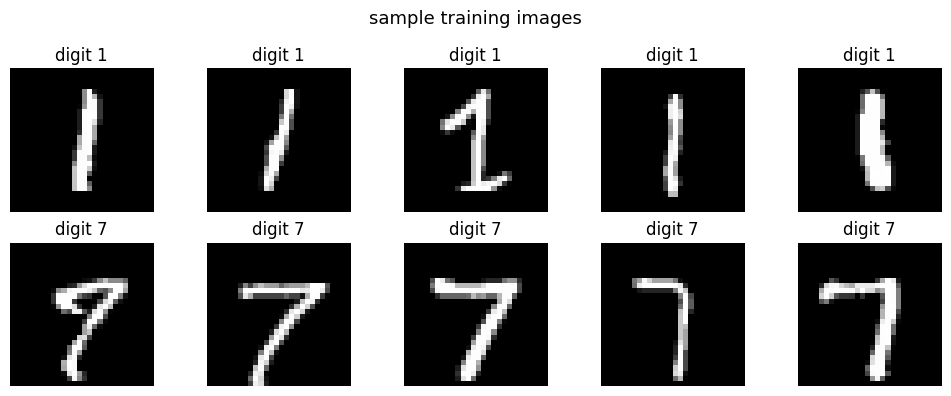

In [16]:
import matplotlib.pyplot as plt

# create a 2 x 5 grid with image ratio as 10 : 4
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, digit in enumerate([1, 7]):
    # find the first 5 indices of the current digit in iteration
    idxs = np.where(y_train == digit)[0][:5]
    for j, idx in enumerate(idxs):
        axes[i, j].imshow(X_train[idx], cmap="gray")
        axes[i, j].axis("off")
        axes[i, j].set_title(f"digit {digit}")

plt.suptitle("sample training images", fontsize=13)
plt.tight_layout()
plt.show()

here, we visualize the five images of each of the two digits that we are going to classify. the style of the digits seem to vary quite a bit

### Data Pre-Processing

we have flatten the array so that linear or non-linear classifiers can use them right 


In [6]:
# flatenning the images from 28x28 to 784
X_train_flat = X_train.reshape(100, -1)
X_test_flat  = X_test.reshape(1000, -1)

# normalizing the pixel values / features
X_train_flat = X_train_flat / 255.0
X_test_flat  = X_test_flat  / 255.0

print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape: ", X_test_flat.shape)
print("Pixel range: min =", X_train_flat.min(), "| max =", X_train_flat.max())

X_train_flat shape: (100, 784)
X_test_flat shape:  (1000, 784)
Pixel range: min = 0.0 | max = 1.0


we normalize our data by dividing it by 255 (highest pixel value). it can have multiple advantages : 

- numerical stability : models internally do lots of multiplications and additions. large values like 255 can cause the numbers to get very large very fast, leading to unstable training or overflow issues

- convergence speed : logistic regression uses gradient descent under the hood. Ssmaller, consistent values help it converge faster and more reliably

- good habit : in practice you almost always normalise, so it's worth building the habit even when it's not strictly critical.

## Building a Classification System

we choose logistic regression as our first classification model

In [22]:
from sklearn.linear_model import LogisticRegression

# creating a logistic regression model and fitting it
lr = LogisticRegression(random_state=42)
lr.fit(X_train_flat, y_train)

# displaying accuracy
print("model trained successfully!")
print("training accuracy:", lr.score(X_train_flat, y_train))

model trained successfully!
training accuracy: 1.0


an accuracy of 1 might mean that the model correctly classified all labels correctly. might indicate overfitting

In [ ]:
from sklearn.metrics import classification_report

# using the logistic regresion model to predict against test set
y_pred_lr = lr.predict(X_test_flat)

print("test accuracy:", lr.score(X_test_flat, y_test))
print("\nclassification report : ")
print(classification_report(y_test, y_pred_lr, target_names=["digit 1", "digit 7"]))

test accuracy: 0.943

classification report : 
              precision    recall  f1-score   support

     digit 1       0.64      1.00      0.78       100
     digit 7       1.00      0.94      0.97       900

    accuracy                           0.94      1000
   macro avg       0.82      0.97      0.87      1000
weighted avg       0.96      0.94      0.95      1000



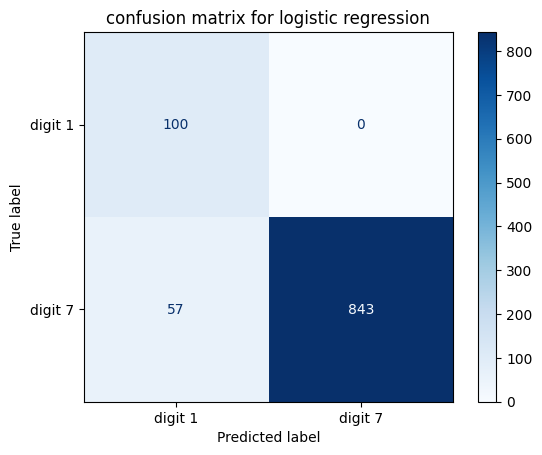

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm, display_labels=["digit 1", "digit 7"])
disp.plot(cmap="Blues")
plt.title("confusion matrix for logistic regression")
plt.show()

# Summary for report

The dataset was loaded from a .npz file, a NumPy archive format that stores multiple named arrays — similar to a dictionary of arrays. Four arrays were extracted: training images, training labels, test images, and test labels.
The training set contains 100 samples and the test set contains 1000 samples, each image being 28×28 pixels in grayscale. Pixel values originally ranged from 0–255, where 0 represents black and 255 represents white.
The training set is perfectly balanced — 50 samples per class. However, the test set is heavily imbalanced — 100 samples of digit 1 vs 900 samples of digit 7 (a 10/90 split). This means raw accuracy alone can be misleading, so evaluation metrics like precision, recall, and F1-score should be reported per class.
Two preprocessing steps were applied:

Flattening — each 28×28 image was reshaped into a 784-dimensional vector, as most classical ML classifiers expect 1D feature vectors.
Normalisation — pixel values were scaled from [0, 255] to [0, 1] by dividing by 255, which improves numerical stability and convergence speed.

Sources:

- NumPy .npz format: https://numpy.org/doc/stable/reference/generated/numpy.load.html
- MNIST dataset description: http://yann.lecun.com/exdb/mnist/
- Feature scaling & normalisation: https://scikit-learn.org/stable/modules/preprocessing.html
- Imbalanced classes & evaluation metrics: https://scikit-learn.org/stable/modules/model_evaluation.html#classification-report